# Air Pollution Analysis in Astana

## Introduction



Air pollution is a critical environmental issue that affects public health, urban sustainability, and quality of life. In rapidly developing cities like Astana, understanding air quality patterns is essential for identifying environmental risks and supporting data-driven decisions.

This project explores air pollution data collected from monitoring stations across the city. The analysis focuses on identifying spatial and temporal patterns, comparing pollutant concentrations, and examining how air quality varies depending on location, time of day, and season.

## Progect Goal

The goal of this project is to analyze air pollution data in Astana and identify key patterns in pollutant concentrations across different stations, time periods, and environmental conditions.

## Dataset Overview

The dataset contains hourly air quality measurements from various monitoring stations in Astana.  
It includes:

- Pollutant values (`value`) with types such as CO, PM10, PM2.5, NO, and SO2.
- Timestamp columns: `date`, `time`, and combined `datetime`.
- Station metadata: name, address, latitude/longitude, status, sea level, etc.
- Season category: heating / non-heating.

Let's explore the structure and basic properties of the dataset.

## Data Cleaning and Preprocessing

Before analysis, the dataset was cleaned and prepared. This included:
- checking for missing values,
- correcting data types,
- removing duplicates (if present),
- converting date and time into a unified datetime format,
- creating additional time-based features such as hour, month, and season.

These steps ensured that the dataset is consistent and ready for analysis.

# Import libraries

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import skew, kurtosis

sns.set(style="whitegrid")

df = pd.read_csv("merged_air_data.csv", sep=';')

df['value'] = df['value'].astype(str).str.replace(",", ".").str.replace(" ", "").astype(float)
df['lat'] = df['lat'].astype(str).str.replace(",", ".").str.replace(" ", "").astype(float)
df['lng'] = df['lng'].astype(str).str.replace(",", ".").str.replace(" ", "").astype(float)

df['datetime'] = pd.to_datetime(df['date'] + " " + df['time'], errors='coerce')
df['hour'] = df['datetime'].dt.hour
df['weekday'] = df['datetime'].dt.day_name()
df['month'] = df['datetime'].dt.month

df.head()


,date,time,stationId,code,value,season,city,station_source,name,address,lat,lng,sea_level,status,datetime,hour,weekday,month
0,4/1/2023,02:00:00,k12,CO,200.41,heating,Astana,KazHydroMet,PCP #6,"Akzhol, distr. of wastewater ""Astana Tazalyk""",51.181287,71.465807,357,ok,2023-04-01 02:00:00,2,Saturday,4
1,4/1/2023,02:00:00,k12,NO,0.00,heating,Astana,KazHydroMet,PCP #6,"Akzhol, distr. of wastewater ""Astana Tazalyk""",51.181287,71.465807,357,ok,2023-04-01 02:00:00,2,Saturday,4
2,4/1/2023,02:00:00,k12,PM10,248.32,heating,Astana,KazHydroMet,PCP #6,"Akzhol, distr. of wastewater ""Astana Tazalyk""",51.181287,71.465807,357,ok,2023-04-01 02:00:00,2,Saturday,4
3,4/1/2023,02:00:00,k12,SO2,31.54,heating,Astana,KazHydroMet,PCP #6,"Akzhol, distr. of wastewater ""Astana Tazalyk""",51.181287,71.465807,357,ok,2023-04-01 02:00:00,2,Saturday,4
4,4/1/2023,02:00:00,k7,CO,469.65,heating,Astana,KazHydroMet,PCP #9,"A. Baitursynov St, 25",51.123121,71.483371,355,ok,2023-04-01 02:00:00,2,Saturday,4


## WHO Air Quality Standards

The World Health Organization (WHO) provides guideline limits for major air pollutants to protect human health. In this project, Astana air pollution data is compared with WHO 24-hour guideline values to assess possible health risks.

The table below summarizes the WHO reference limits used in this analysis.

In [16]:

who_rows = [
    {"Pollutant": "PM2.5", "WHO limit": 15, "Unit": "µg/m³", "Averaging": "24-hour",
     "Health note": "Cardio-respiratory risk"},
    {"Pollutant": "PM10",  "WHO limit": 45, "Unit": "µg/m³", "Averaging": "24-hour",
     "Health note": "Respiratory irritation/asthma"},
    {"Pollutant": "SO2",   "WHO limit": 40, "Unit": "µg/m³", "Averaging": "24-hour",
     "Health note": "Worsens asthma, lung inflammation"},
   
    {"Pollutant": "NO (ref: NO2)", "WHO limit": 25, "Unit": "µg/m³", "Averaging": "24-hour",
     "Health note": "Reduced lung function (NO2 guideline)"},
    {"Pollutant": "CO",    "WHO limit": 4,  "Unit": "mg/m³", "Averaging": "24-hour",
     "Health note": "Reduces O2 delivery; cardiovascular effects"},
]
who_tbl = pd.DataFrame(who_rows)
who_tbl


,Pollutant,WHO limit,Unit,Averaging,Health note
0,PM2.5,15,µg/m³,24-hour,Cardio-respiratory risk
1,PM10,45,µg/m³,24-hour,Respiratory irritation/asthma
2,SO2,40,µg/m³,24-hour,"Worsens asthma, lung inflammation"
3,NO (ref: NO2),25,µg/m³,24-hour,Reduced lung function (NO2 guideline)
4,CO,4,mg/m³,24-hour,Reduces O2 delivery; cardiovascular effects


These limits serve as a benchmark for evaluating whether observed pollutant concentrations in Astana exceed recommended health-based thresholds.

# Data Visualization

### CO Pollution Over Time

This chart shows the daily average concentration of carbon monoxide (CO) over the observed period. The black line represents a 7-day rolling average, which helps highlight overall trends, while the dashed line indicates the WHO recommended limit.

Analyzing CO levels over time allows us to identify fluctuations and periods of increased pollution.



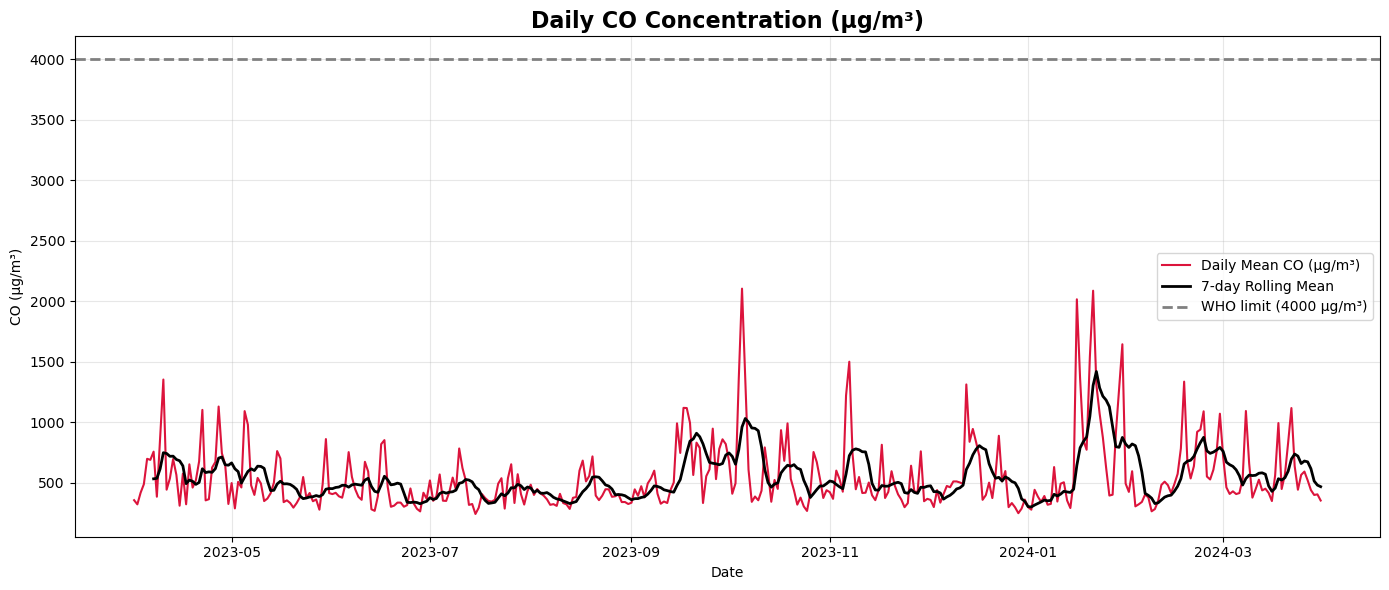

In [1]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("merged_air_data.csv", sep=";")


df['value'] = pd.to_numeric(df['value'].astype(str).str.replace(",", "."), errors='coerce')


if 'datetime' not in df.columns:
    df['datetime'] = pd.to_datetime(df['date'] + " " + df['time'], errors='coerce')
else:
    df['datetime'] = pd.to_datetime(df['datetime'], errors='coerce')


mask = df['code'].str.upper() == 'CO'
co = df[mask].copy()


daily = co.groupby(co['datetime'].dt.date)['value'].mean()

# WHO limit 4 mg/m³ = 4000 µg/m³
WHO_LIMIT = 4000  


plt.figure(figsize=(14,6))
plt.plot(daily.index, daily.values, color="crimson", linewidth=1.5, label="Daily Mean CO (µg/m³)")
plt.plot(daily.index, daily.rolling(7).mean(), color="black", linewidth=2, label="7-day Rolling Mean")
plt.axhline(WHO_LIMIT, color="gray", linestyle="--", linewidth=2, label="WHO limit (4000 µg/m³)")

plt.title("Daily CO Concentration (µg/m³)", fontsize=16, weight="bold")
plt.xlabel("Date")
plt.ylabel("CO (µg/m³)")
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


The graph shows that CO concentrations vary over time, with several noticeable peaks. However, most values remain below the WHO recommended limit.

These fluctuations may be associated with factors such as traffic intensity or seasonal conditions. Although the overall level appears relatively stable, short-term increases in CO concentration may still pose potential health risks.

### Pollution Trends by Pollutant

The following charts show daily average concentrations of major pollutants (PM10, PM2.5, SO2, and NO) over time. Each plot includes the WHO recommended limit for comparison.

This allows us to analyze how pollution levels change over time and identify periods when air quality may exceed safe thresholds.

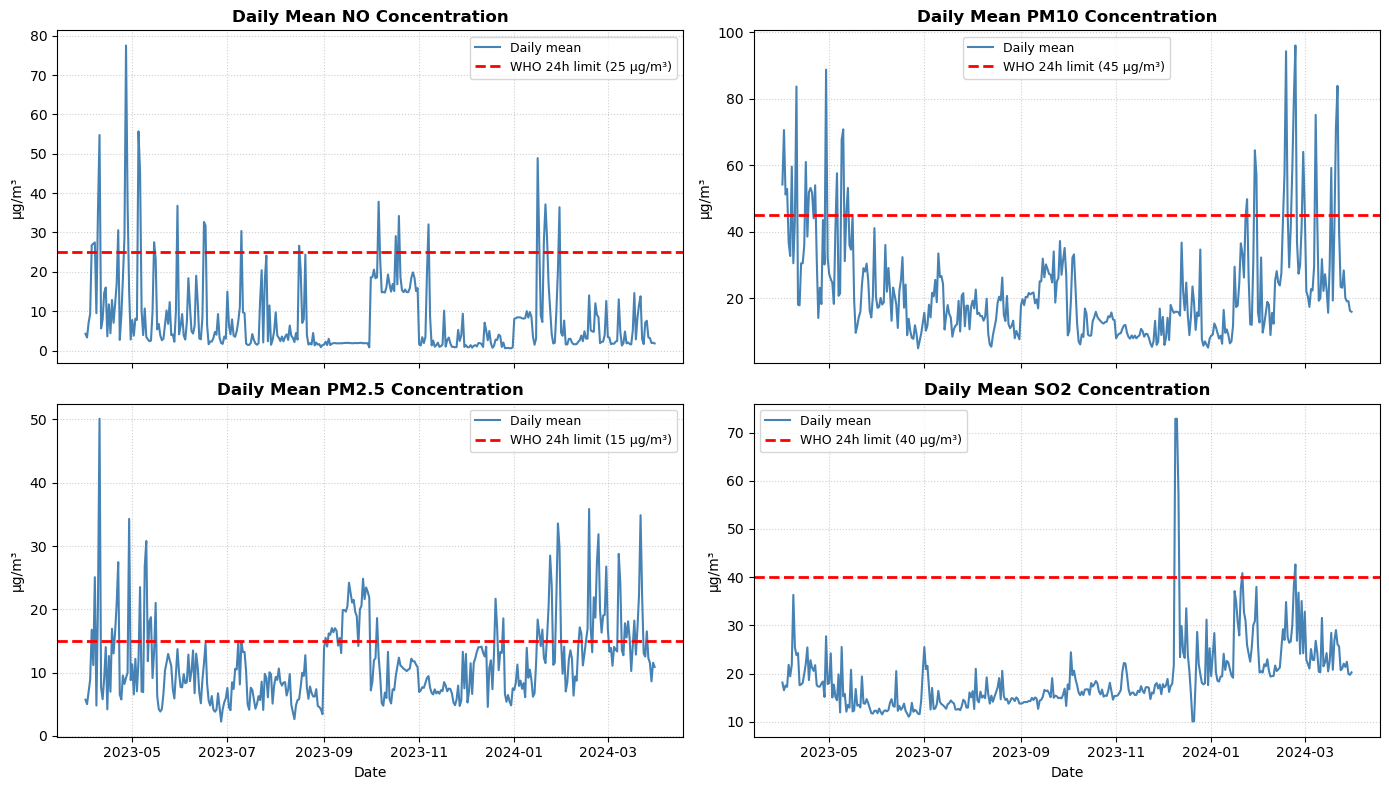

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# =========================
# 1. Load data
# =========================
df = pd.read_csv("merged_air_data.csv", sep=";")
df.columns = [c.strip().lower() for c in df.columns]

# numeric values
df["value"] = pd.to_numeric(
    df["value"].astype(str).str.replace(",", "."),
    errors="coerce"
)

# datetime handling
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
else:
    df["datetime"] = pd.to_datetime(
        df["date"].astype(str) + " " + df["time"].astype(str),
        errors="coerce"
    )

# =========================
# 2. Select pollutants (NO CO!)
# =========================
pollutants = ["NO", "PM10", "PM2.5", "SO2"]
df = df[df["code"].isin(pollutants)].copy()

# =========================
# 3. Daily mean values
# =========================
df["date"] = df["datetime"].dt.date
daily_mean = df.groupby(["date", "code"])["value"].mean().reset_index()

# =========================
# 4. WHO 24-hour standards (µg/m³)
# =========================
who_limits = {
    "NO": 25,
    "PM10": 45,
    "PM2.5": 15,
    "SO2": 40
}

# =========================
# 5. Plot
# =========================
fig, axes = plt.subplots(2, 2, figsize=(14, 8), sharex=True)
axes = axes.flatten()

for i, pollutant in enumerate(pollutants):
    ax = axes[i]

    data_p = daily_mean[daily_mean["code"] == pollutant]

    ax.plot(
        data_p["date"],
        data_p["value"],
        color="steelblue",
        linewidth=1.5,
        label="Daily mean"
    )

    ax.axhline(
        who_limits[pollutant],
        color="red",
        linestyle="--",
        linewidth=2,
        label=f"WHO 24h limit ({who_limits[pollutant]} µg/m³)"
    )

    ax.set_title(f"Daily Mean {pollutant} Concentration", fontsize=12, weight="bold")
    ax.set_ylabel("µg/m³")
    ax.grid(True, linestyle=":", alpha=0.6)
    ax.legend(fontsize=9)

# X label only for bottom plots
for ax in axes[2:]:
    ax.set_xlabel("Date")

plt.tight_layout()
plt.show()



The graphs show that pollution levels vary over time for all pollutants, with several noticeable peaks. In some cases, concentrations exceed WHO recommended limits, indicating potential health risks.

PM10 and PM2.5 demonstrate more frequent fluctuations, suggesting they play a major role in overall air pollution. These patterns highlight the importance of continuous monitoring and pollution control measures.

### Daily Pattern of CO Pollution

This section analyzes how CO pollution levels change throughout the day.  
The data is grouped by hour to identify daily patterns and peak pollution periods.


C:\Users\Admin\AppData\Local\Temp\ipykernel_35364\1891693270.py:27: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df_co, x='hour', y='value_mg', estimator='mean', ci='sd')


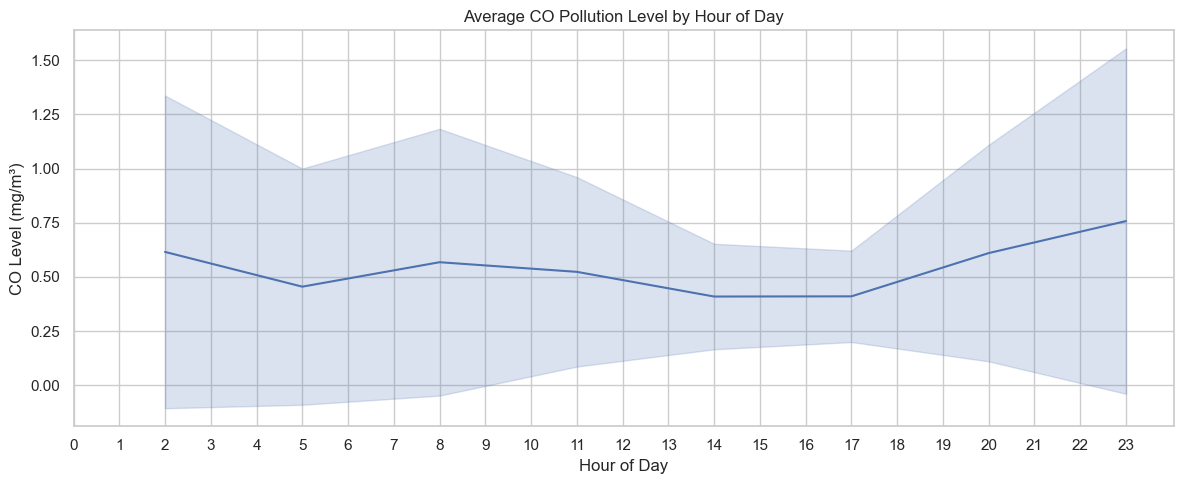

In [13]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("merged_air_data.csv", sep=';')


df['datetime'] = pd.to_datetime(df['date'] + ' ' + df['time'], errors='coerce')
df['hour'] = df['datetime'].dt.hour


df['value'] = df['value'].astype(str).str.replace(",", ".").str.replace(" ", "").astype(float)


df_co = df[df['code'] == 'CO'].copy()
df_other = df[df['code'] != 'CO']


df_co['value_mg'] = df_co['value'] / 1000.0


sns.set(style="whitegrid")


plt.figure(figsize=(12, 5))
sns.lineplot(data=df_co, x='hour', y='value_mg', estimator='mean', ci='sd')
plt.title('Average CO Pollution Level by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('CO Level (mg/m³)')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()


CO concentration varies throughout the day, with noticeable changes depending on the hour.

The highest levels are observed during nighttime and early morning hours, which may be linked to heating systems and reduced air circulation. Lower levels during the day suggest improved dispersion due to increased temperature and wind activity.

This pattern indicates that air pollution is influenced not only by emissions but also by environmental conditions.

### Daily Patterns of Air Pollutants (Excluding CO)

This section analyzes how different pollutants (PM10, PM2.5, SO2, and NO) vary throughout the day.

By grouping data by hour, we can identify patterns in pollution levels and understand how human activity and environmental conditions affect air quality.

C:\Users\Admin\AppData\Local\Temp\ipykernel_35652\697147724.py:2: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  sns.lineplot(data=df_other, x='hour', y='value', hue='code', estimator='mean', ci='sd')


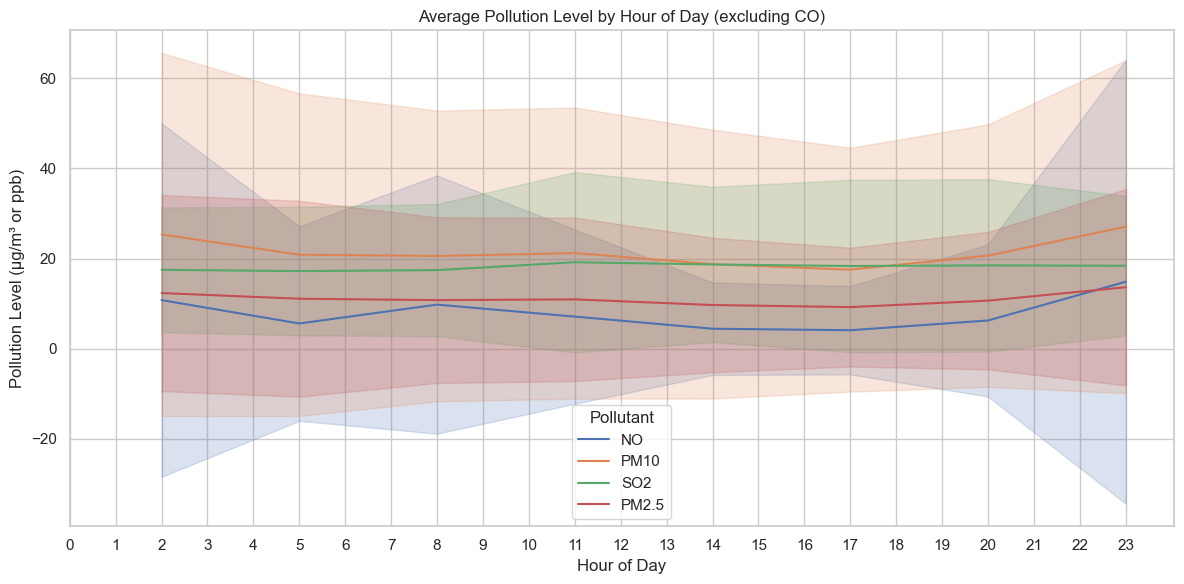

In [31]:
plt.figure(figsize=(12, 6))
sns.lineplot(data=df_other, x='hour', y='value', hue='code', estimator='mean', ci='sd')
plt.title('Average Pollution Level by Hour of Day (excluding CO)')
plt.xlabel('Hour of Day')
plt.ylabel('Pollution Level (µg/m³ or ppb)')
plt.legend(title='Pollutant')
plt.xticks(range(0, 24))
plt.tight_layout()
plt.show()

All pollutants show similar daily patterns, with fluctuations depending on the time of day.

Pollution levels tend to be higher during nighttime and early morning hours, possibly due to reduced air circulation and heating emissions. During daytime, levels are generally lower, likely due to better dispersion conditions.

Among the pollutants, PM10 and PM2.5 appear to have more stable but consistently elevated levels, indicating their significant contribution to overall air pollution.

### Weekly Patterns of Air Pollution

This section examines how pollution levels vary across different days of the week.

By comparing weekday and weekend patterns, we can identify whether human activity (such as traffic and industrial operations) influences air pollution levels.


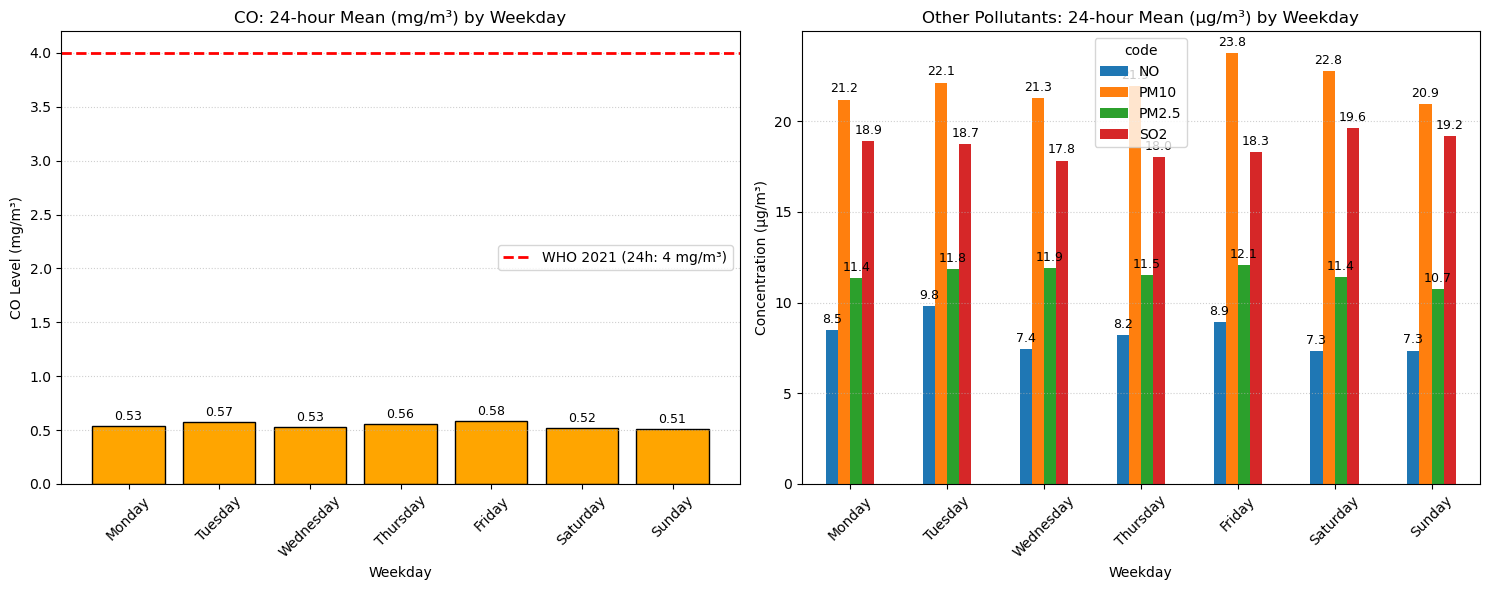

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# -------- settings --------
CSV_PATH = "merged_air_data.csv"
WEEK_ORDER = ["Monday","Tuesday","Wednesday","Thursday","Friday","Saturday","Sunday"]
WHO_CO = 4.0   # mg/m³

# -------- load --------
df = pd.read_csv(CSV_PATH, sep=";")
df.columns = [c.strip().lower() for c in df.columns]

df["value"] = pd.to_numeric(df["value"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

# date -> weekday
df["date"] = pd.to_datetime(df["date"], format="mixed", errors="coerce")
df["weekday"] = df["date"].dt.day_name()

# -------- CO (mg/m³) --------
co = df[df["code"].str.upper() == "CO"].copy()
co["value_mg_m3"] = co["value"] / 1000.0   # µg/m³ -> mg/m³
co_week = co.groupby("weekday")["value_mg_m3"].mean().reindex(WEEK_ORDER)

# -------- Other pollutants (µg/m³) --------
other_codes = ["PM2.5", "PM10", "SO2", "NO"]
others = df[df["code"].isin(other_codes)].copy()

other_week = (
    others.groupby(["weekday", "code"])["value"]
          .mean()
          .unstack("code")
          .reindex(WEEK_ORDER)
)

# -------- Plot side-by-side --------
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# (1) CO barplot + WHO line + value labels
bars = axes[0].bar(co_week.index, co_week.values, color="orange", edgecolor="black")
axes[0].axhline(WHO_CO, linestyle="--", linewidth=2, color="red", label="WHO 2021 (24h: 4 mg/m³)")
axes[0].set_title("CO: 24-hour Mean (mg/m³) by Weekday")
axes[0].set_ylabel("CO Level (mg/m³)")
axes[0].set_xlabel("Weekday")
axes[0].tick_params(axis="x", rotation=45)
axes[0].legend()
axes[0].grid(axis="y", linestyle=":", alpha=0.6)


for rect in bars:
    h = rect.get_height()
    axes[0].text(rect.get_x() + rect.get_width()/2, h + 0.03, f"{h:.2f}",
                 ha="center", va="bottom", fontsize=9)


ax2 = other_week.plot(kind="bar", ax=axes[1])
axes[1].set_title("Other Pollutants: 24-hour Mean (µg/m³) by Weekday")
axes[1].set_ylabel("Concentration (µg/m³)")
axes[1].set_xlabel("Weekday")
axes[1].tick_params(axis="x", rotation=45)
axes[1].grid(axis="y", linestyle=":", alpha=0.6)


for container in axes[1].containers:
    axes[1].bar_label(container, fmt="%.1f", padding=3, fontsize=9)

plt.tight_layout()
plt.show()


The results show that pollution levels remain relatively stable throughout the week, with only slight variations between weekdays and weekends.

CO levels do not show significant differences, suggesting that daily emissions are relatively consistent.

For other pollutants, small increases can be observed on certain days, which may be linked to variations in traffic or urban activity. However, no strong weekly pattern is detected.

This indicates that air pollution in the city is influenced by continuous sources rather than short-term weekly changes.

Overall, the lack of strong weekly differences indicates that structural factors, such as heating systems and urban infrastructure, have a greater impact on air pollution than daily behavioral patterns.

### Seasonal Comparison: Heating vs Non-heating Period

This section compares pollution levels between the heating and non-heating seasons.

In cold climates like Astana, the heating season is associated with increased fuel consumption, particularly from coal-based heating systems. Therefore, we expect higher pollution levels during this period.

The following charts illustrate the average concentrations of CO and other pollutants across the two seasons.

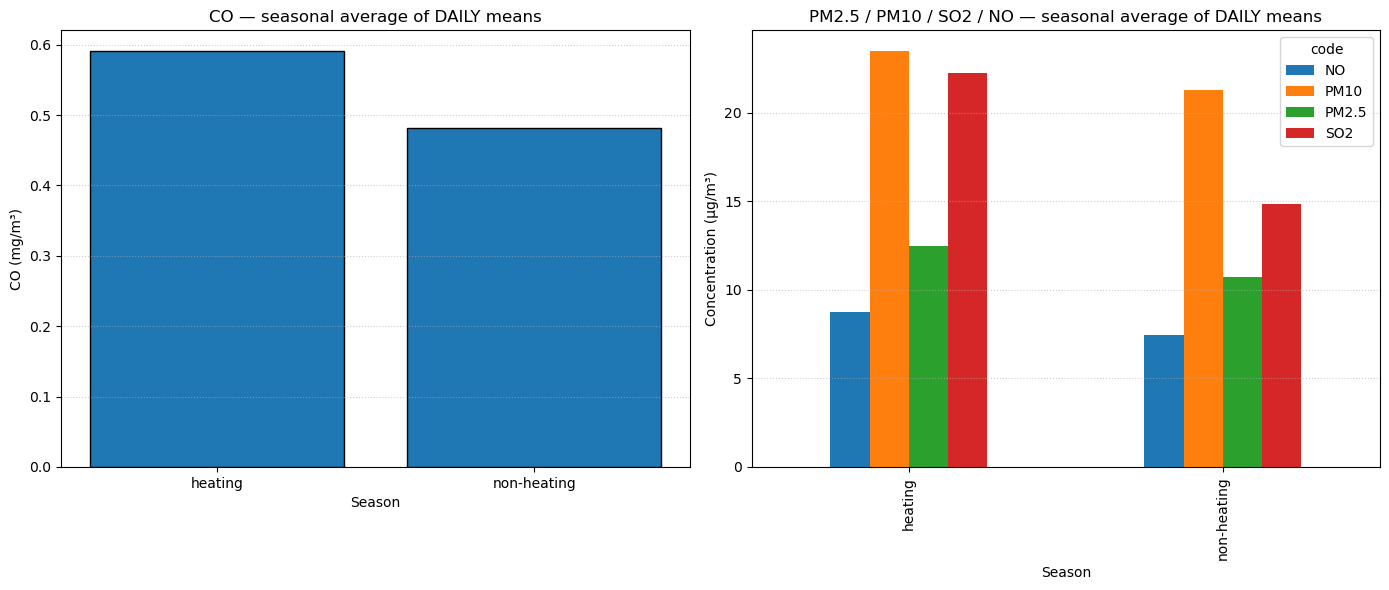


CO — seasonal avg of daily means (mg/m³):
 season
heating        0.591
non-heating    0.481
Name: value_mg_m3, dtype: float64

Other pollutants — seasonal avg of daily means (µg/m³):
 code           NO   PM10  PM2.5    SO2
season                                
heating      8.77  23.48  12.49  22.23
non-heating  7.48  21.28  10.74  14.85


In [13]:


import pandas as pd
import matplotlib.pyplot as plt


CSV_PATH = "merged_air_data.csv"      
SEASONS = ["heating", "non-heating"]  


df = pd.read_csv(CSV_PATH, sep=";")


df["value"] = df["value"].astype(str).str.replace(",", ".", regex=False).astype(float)


df["date"] = pd.to_datetime(df["date"], format="mixed", errors="coerce")


df["day"] = df["date"].dt.date


co = df[df["code"] == "CO"].copy()
co["value_mg_m3"] = co["value"] / 1000.0  # µg/m³ -> mg/m³


co_daily = (
    co.groupby(["season", "day"])["value_mg_m3"]
      .mean()
      .reset_index()
)


co_seasonal = (
    co_daily.groupby("season")["value_mg_m3"]
            .mean()
            .reindex(SEASONS)
)


other_codes = ["PM2.5", "PM10", "SO2", "NO"]   
others = df[df["code"].isin(other_codes)].copy()

others_daily = (
    others.groupby(["season", "day", "code"])["value"]
          .mean()
          .reset_index()
)


others_seasonal = (
    others_daily.groupby(["season", "code"])["value"]
                .mean()
                .unstack("code")
                .reindex(SEASONS)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))


axes[0].bar(co_seasonal.index, co_seasonal.values, edgecolor="black")
axes[0].set_title("CO — seasonal average of DAILY means")
axes[0].set_xlabel("Season")
axes[0].set_ylabel("CO (mg/m³)")
axes[0].grid(axis="y", linestyle=":", alpha=0.6)


others_seasonal.plot(kind="bar", ax=axes[1])
axes[1].set_title("PM2.5 / PM10 / SO2 / NO — seasonal average of DAILY means")
axes[1].set_xlabel("Season")
axes[1].set_ylabel("Concentration (µg/m³)")
axes[1].grid(axis="y", linestyle=":", alpha=0.6)

plt.tight_layout()
plt.show()


print("\nCO — seasonal avg of daily means (mg/m³):\n", co_seasonal.round(3))
print("\nOther pollutants — seasonal avg of daily means (µg/m³):\n", others_seasonal.round(2))


Pollution levels are significantly higher during the heating season compared to the non-heating season.

CO concentration increases from approximately 0.49 mg/m³ to 0.59 mg/m³, indicating a noticeable rise during winter months.

A similar pattern is observed for all other pollutants (PM10, PM2.5, SO2, and NO), which show consistently higher values during the heating season. The increase is particularly strong for PM10 and SO2.

This clearly indicates that heating-related emissions are a major contributor to air pollution in the city.

Overall, seasonal variation has a much stronger impact on air quality than daily or weekly patterns.

### Seasonal Comparison by Station

This section analyzes how pollution levels vary across different monitoring stations during the heating and non-heating seasons.

The analysis includes multiple pollutants (CO, PM10, PM2.5, SO2, and NO) to identify whether seasonal effects are consistent across different types of emissions.

The goal is to examine both seasonal variation and spatial differences in air pollution across the city.

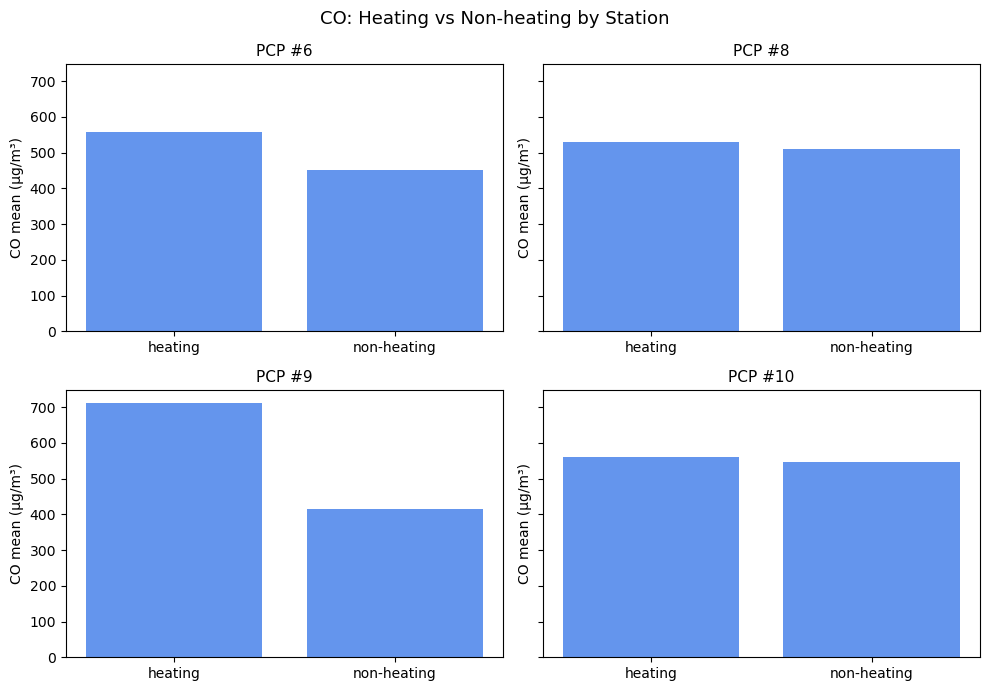

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("merged_air_data.csv", sep=';')

pollutant = 'CO'
stations_to_plot = ['PCP #6', 'PCP #8', 'PCP #9', 'PCP #10']

sub = df[(df['code'] == pollutant) & (df['name'].isin(stations_to_plot))].copy()


sub['value'] = (
    sub['value']
    .astype(str)
    .str.replace(',', '.', regex=False)
)
sub['value'] = pd.to_numeric(sub['value'], errors='coerce')


sub = sub.dropna(subset=['value', 'season', 'name'])

agg = (
    sub.groupby(['name', 'season'], as_index=False)['value']
       .mean()
       .rename(columns={'value': 'mean_value'})
)

season_order = ['heating', 'non-heating']
agg['season'] = pd.Categorical(
    agg['season'],
    categories=season_order,
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for ax, st in zip(axes, stations_to_plot):
    d = agg[agg['name'] == st].sort_values('season')
    ax.bar(d['season'].astype(str), d['mean_value'], color='cornflowerblue')
    ax.set_title(st, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("CO mean (µg/m³)")

for j in range(len(stations_to_plot), 4):
    fig.delaxes(axes[j])

fig.suptitle("CO: Heating vs Non-heating by Station", fontsize=13)
plt.tight_layout()
plt.show()


CO levels show different seasonal patterns across monitoring stations.

At PCP #6, CO concentration is noticeably higher during the heating season compared to the non-heating period, indicating a clear impact of heating emissions.

At PCP #9, the seasonal difference is even more pronounced, with a significant increase in CO levels during the heating season. This suggests that this station is strongly affected by heating-related sources.

In contrast, PCP #8 and PCP #10 show minimal differences between heating and non-heating seasons, indicating that CO levels at these locations are relatively stable and less influenced by seasonal factors.

Overall, the impact of the heating season on CO pollution is uneven across the city, with certain areas experiencing much stronger increases than others.

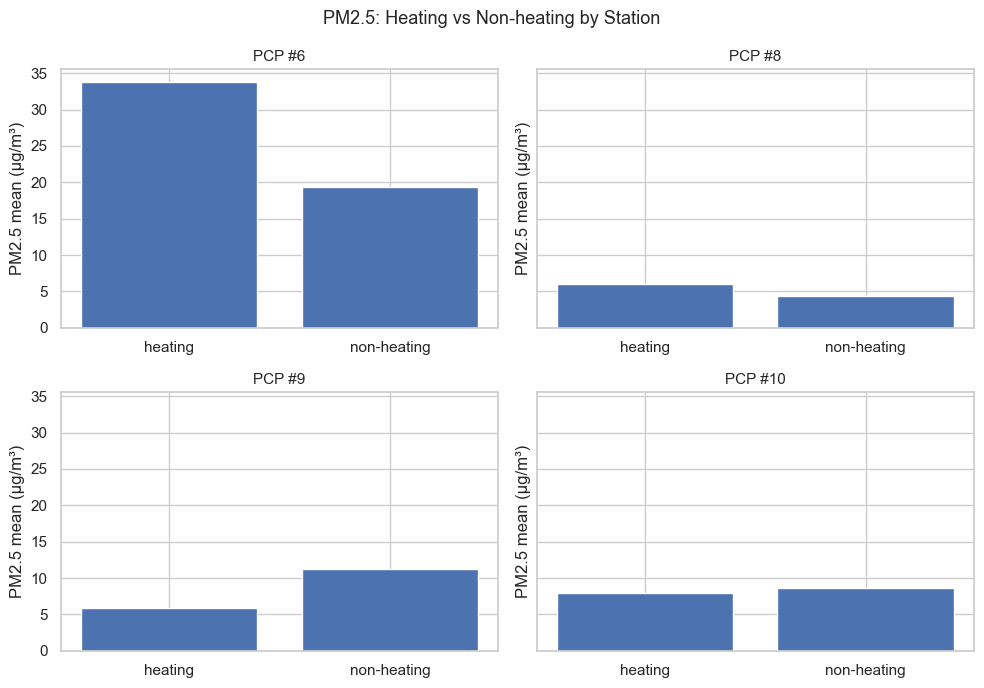

In [13]:
import pandas as pd
import matplotlib.pyplot as plt


df = pd.read_csv("merged_air_data.csv", sep=';')  


df['value'] = (
    df['value'].astype(str).str.replace(",", ".", regex=False).str.replace(" ", "", regex=False).astype(float)
)


if 'datetime' not in df.columns:
    df['datetime'] = pd.to_datetime(df['date'].astype(str) + " " + df['time'], errors='coerce')


pollutant = 'PM2.5'  
stations_to_plot = ['PCP #6', 'PCP #8', 'PCP #9', 'PCP #10']  


stations_to_plot = [s for s in stations_to_plot if s in df['name'].unique()]
if len(stations_to_plot) == 0:
    raise ValueError("Выбранные станции не найдены в данных. Проверь названия.")

sub = df[(df['code'] == pollutant) & (df['name'].isin(stations_to_plot))].copy()

agg = (sub.groupby(['name', 'season'], as_index=False)['value']
          .mean()
          .rename(columns={'value': 'mean_value'}))


season_order = ['heating', 'non-heating']
agg['season'] = pd.Categorical(agg['season'], categories=season_order, ordered=True)


fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for ax, st in zip(axes, stations_to_plot):
    d = agg[agg['name'] == st].sort_values('season')
    ax.bar(d['season'].astype(str), d['mean_value'])
    ax.set_title(st, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel(f"{pollutant} mean (µg/m³)" if pollutant != 'CO' else "CO mean (mg/m³)")
   


for j in range(len(stations_to_plot), 4):
    fig.delaxes(axes[j])

fig.suptitle(f"{pollutant}: Heating vs Non-heating by Station", fontsize=13)
plt.tight_layout()
plt.show()


PM2.5 levels show significant variation across monitoring stations and do not follow a uniform seasonal pattern.

At PCP #6, PM2.5 concentration is substantially higher during the heating season, indicating a strong impact of heating-related emissions.

In contrast, at PCP #9, PM2.5 levels are higher during the non-heating season, suggesting that other factors, such as traffic or local environmental conditions, may play a more important role.

At PCP #8 and PCP #10, the differences between seasons are relatively small, indicating more stable pollution levels throughout the year.

Overall, PM2.5 pollution demonstrates both seasonal and location-specific variability, highlighting the complexity of its sources.

C:\Users\Admin\AppData\Local\Temp\ipykernel_37044\1391451717.py:28: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Admin\anaconda3\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


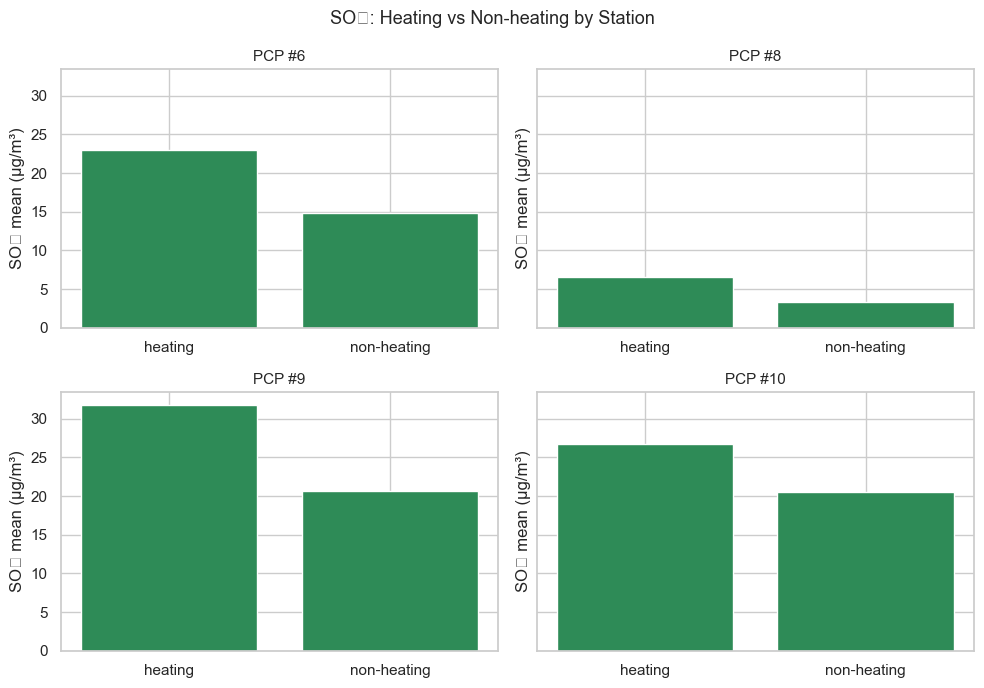

In [14]:

pollutant = 'SO2'
stations_to_plot = ['PCP #6', 'PCP #8', 'PCP #9', 'PCP #10']  # нужные станции

sub = df[(df['code'] == pollutant) & (df['name'].isin(stations_to_plot))].copy()

agg = (sub.groupby(['name', 'season'], as_index=False)['value']
          .mean()
          .rename(columns={'value': 'mean_value'}))

season_order = ['heating', 'non-heating']
agg['season'] = pd.Categorical(agg['season'], categories=season_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for ax, st in zip(axes, stations_to_plot):
    d = agg[agg['name'] == st].sort_values('season')
    ax.bar(d['season'].astype(str), d['mean_value'], color="seagreen")
    ax.set_title(st, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("SO₂ mean (µg/m³)")

for j in range(len(stations_to_plot), 4):
    fig.delaxes(axes[j])

fig.suptitle("SO₂: Heating vs Non-heating by Station", fontsize=13)
plt.tight_layout()
plt.show()


SO₂ concentrations are consistently higher during the heating season across all monitoring stations.

The most significant differences are observed at PCP #9 and PCP #10, where SO₂ levels increase substantially in the heating period.

At PCP #6, a clear increase is also visible, although less pronounced, while PCP #8 shows lower overall levels but still follows the same seasonal pattern.

This consistent trend suggests that heating-related emissions are the primary source of SO₂ pollution in the area.

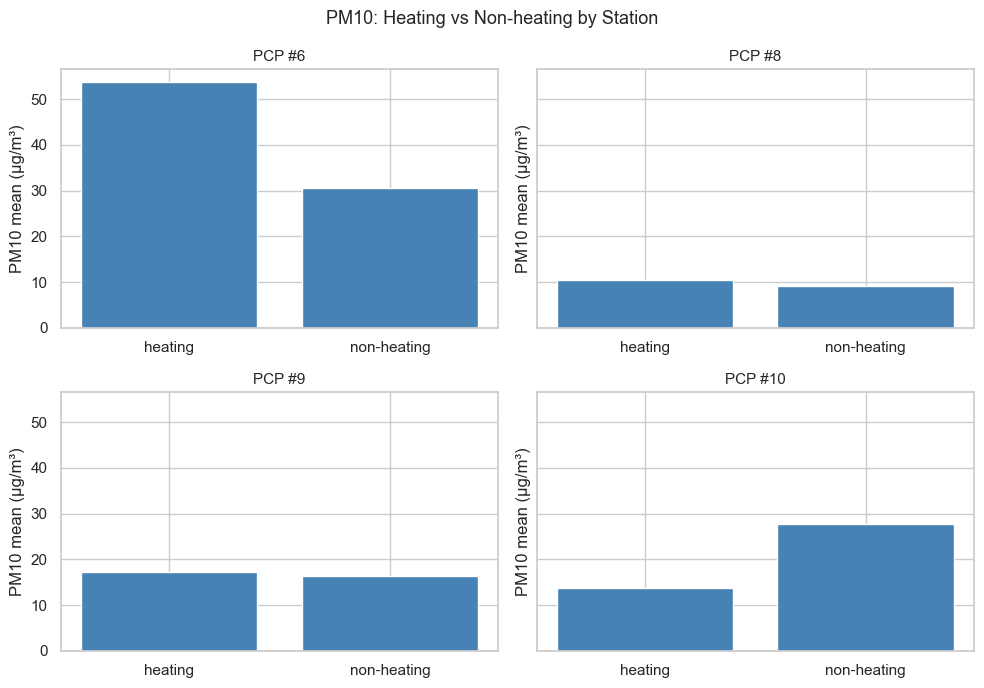

In [15]:

pollutant = 'PM10'
stations_to_plot = ['PCP #6', 'PCP #8', 'PCP #9', 'PCP #10']  

sub = df[(df['code'] == pollutant) & (df['name'].isin(stations_to_plot))].copy()

agg = (sub.groupby(['name', 'season'], as_index=False)['value']
          .mean()
          .rename(columns={'value': 'mean_value'}))

season_order = ['heating', 'non-heating']
agg['season'] = pd.Categorical(agg['season'], categories=season_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for ax, st in zip(axes, stations_to_plot):
    d = agg[agg['name'] == st].sort_values('season')
    ax.bar(d['season'].astype(str), d['mean_value'], color="steelblue")
    ax.set_title(st, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("PM10 mean (µg/m³)")

for j in range(len(stations_to_plot), 4):
    fig.delaxes(axes[j])

fig.suptitle("PM10: Heating vs Non-heating by Station", fontsize=13)
plt.tight_layout()
plt.show()


PM10 concentrations vary significantly across monitoring stations and do not follow a consistent seasonal pattern.

At PCP #6, PM10 levels are notably higher during the heating season, indicating a strong influence of heating-related emissions.

In contrast, at PCP #10, PM10 concentrations are higher during the non-heating season, suggesting that non-heating sources such as dust or traffic may play a more significant role.

At PCP #8 and PCP #9, PM10 levels remain relatively stable across seasons, showing minimal variation.

Overall, PM10 pollution appears to be influenced by both seasonal factors and local environmental conditions rather than a single dominant source.

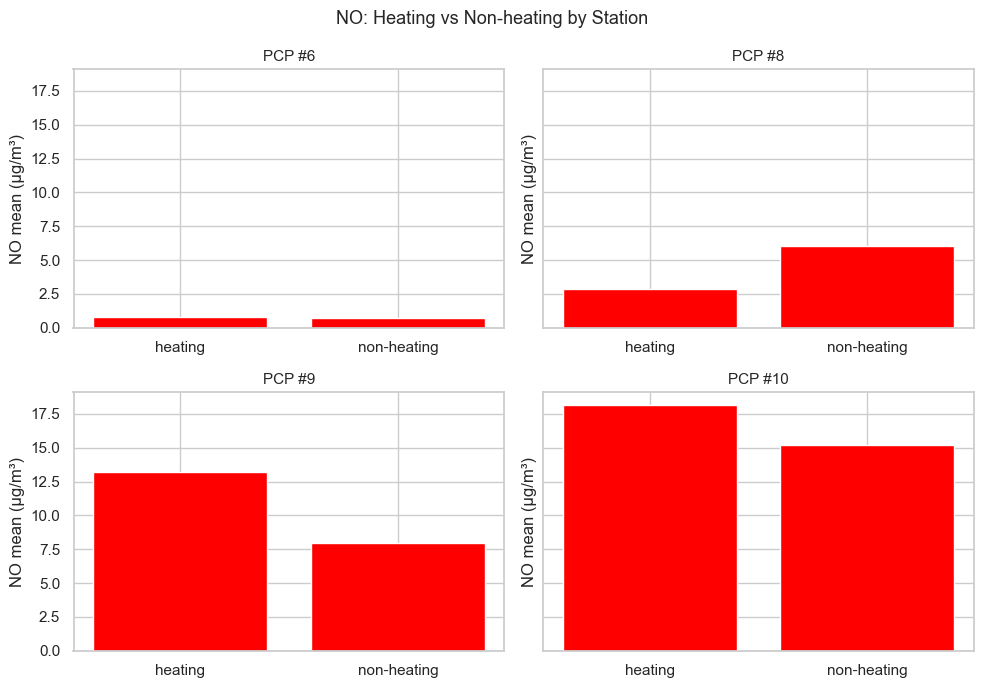

In [17]:

pollutant = 'NO'
stations_to_plot = ['PCP #6', 'PCP #8', 'PCP #9', 'PCP #10']  

sub = df[(df['code'] == pollutant) & (df['name'].isin(stations_to_plot))].copy()

agg = (sub.groupby(['name', 'season'], as_index=False)['value']
          .mean()
          .rename(columns={'value': 'mean_value'}))

season_order = ['heating', 'non-heating']
agg['season'] = pd.Categorical(agg['season'], categories=season_order, ordered=True)

fig, axes = plt.subplots(2, 2, figsize=(10, 7), sharey=True)
axes = axes.flatten()

for ax, st in zip(axes, stations_to_plot):
    d = agg[agg['name'] == st].sort_values('season')
    ax.bar(d['season'].astype(str), d['mean_value'], color="red")
    ax.set_title(st, fontsize=11)
    ax.set_xlabel("")
    ax.set_ylabel("NO mean (µg/m³)")

for j in range(len(stations_to_plot), 4):
    fig.delaxes(axes[j])

fig.suptitle("NO: Heating vs Non-heating by Station", fontsize=13)
plt.tight_layout()
plt.show()


NO₂ concentrations show notable variation across monitoring stations and do not follow a consistent seasonal pattern.

At PCP #9 and PCP #10, NO₂ levels are higher during the heating season, suggesting an influence of combustion-related emissions.

However, at PCP #8, NO₂ concentrations are higher during the non-heating season, indicating that traffic or urban activity may play a more significant role.

At PCP #6, NO₂ levels remain very low and show minimal seasonal variation.

Overall, NO₂ pollution appears to be influenced by both seasonal heating and local emission sources such as traffic.

## Conclusion

The analysis of air pollution in Astana reveals that different pollutants are influenced by different sources and seasonal factors.

SO₂ shows a strong and consistent increase during the heating season across all monitoring stations, indicating that it is primarily driven by heating-related emissions.

CO also tends to be higher during the heating period, although the pattern is less pronounced and varies slightly between locations.

In contrast, PM2.5 and PM10 do not follow a consistent seasonal pattern. Their concentrations vary significantly across stations, suggesting that local factors such as traffic, dust, and urban activity play a major role.

Similarly, NO₂ shows mixed behavior: in some locations it increases during the heating season, while in others it is higher during the non-heating period, indicating a strong influence of traffic emissions.

Overall, the results demonstrate that air pollution in Astana is a complex issue driven by both seasonal heating and local urban sources, with each pollutant having different dominant factors.

### Monthly Pattern of CO Pollution

This chart shows the average daily concentration of CO by month. The purpose of this analysis is to identify whether carbon monoxide levels change across the year and to detect possible seasonal peaks.

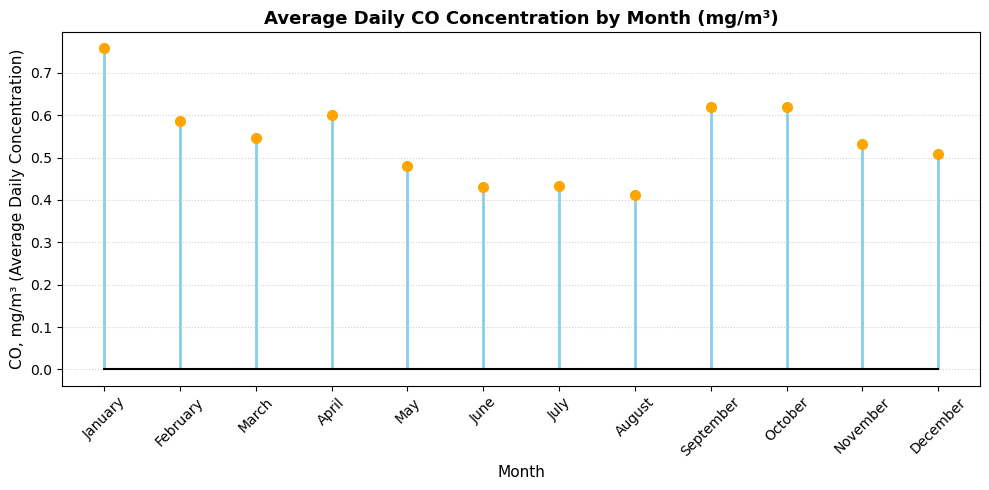

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load and prepare data ===
df = pd.read_csv("merged_air_data.csv", sep=';')
df.columns = [c.strip().lower() for c in df.columns]
df["value"] = pd.to_numeric(df["value"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

if "datetime" not in df.columns:
    if {"date","time"}.issubset(df.columns):
        df["datetime"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str), errors="coerce")
    elif "date" in df.columns:
        df["datetime"] = pd.to_datetime(df["date"], errors="coerce")
    else:
        df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")

# === 2. Filter CO and convert µg/m³ → mg/m³ ===
co = df[df["code"].astype(str).str.upper().str.strip() == "CO"].copy()
co["value_mg"] = co["value"] / 1000.0

# === 3. Daily averages ===
co["date"] = co["datetime"].dt.date
daily = co.groupby("date", as_index=False)["value_mg"].mean()

# === 4. Monthly averages ===
daily["month"] = pd.to_datetime(daily["date"]).dt.month_name()
month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']
monthly_mean = daily.groupby("month")["value_mg"].mean().reindex(month_order)

# === 5. Stem plot (sky blue lines + orange dots) ===
plt.figure(figsize=(10,5))
(markerline, stemlines, baseline) = plt.stem(monthly_mean.index, monthly_mean.values,
                                             linefmt='skyblue', markerfmt='o', basefmt='k-')
plt.setp(stemlines, linewidth=2, color='skyblue')     # blue stems
plt.setp(markerline, markersize=7, markerfacecolor='orange', markeredgecolor='orange')  # orange dots

# === 6. Labels and style ===
plt.title("Average Daily CO Concentration by Month (mg/m³)", fontsize=13, weight='bold')
plt.xlabel("Month", fontsize=11)
plt.ylabel("CO, mg/m³ (Average Daily Concentration)", fontsize=11)
plt.xticks(rotation=45)
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()


CO concentrations vary moderately across the year, with the highest values observed in January and relatively elevated levels again in September and October.

The lowest monthly averages appear in summer, especially in June, July, and August. This suggests that CO pollution tends to increase during colder months and decrease during warmer periods.

Overall, the monthly pattern indicates a seasonal effect, although the variation is less pronounced than for some other pollutants.

### Monthly Pattern of Other Pollutants

This chart presents the average daily concentrations of NO, PM10, SO2, and PM2.5 by month. It helps identify seasonal variation and compare how different pollutants behave throughout the year.

Used pollutants: ['NO', 'PM10', 'SO2', 'PM2.5']


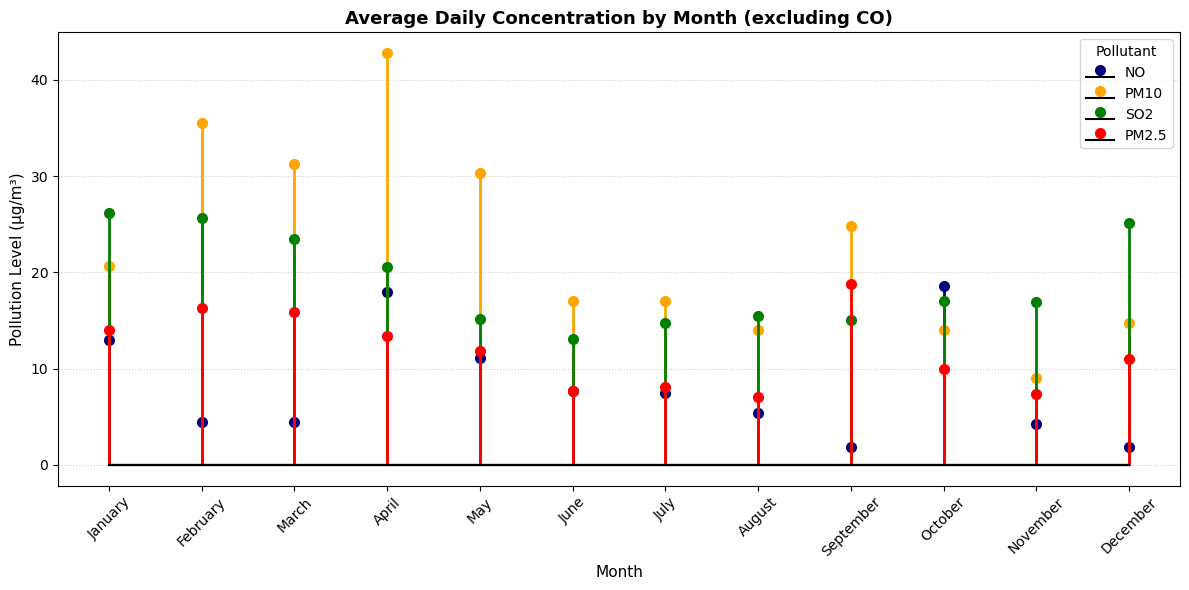

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# === 1. Load and prepare data ===
df = pd.read_csv("merged_air_data.csv", sep=';')
df.columns = [c.strip().lower() for c in df.columns]
df["value"] = pd.to_numeric(df["value"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

if "datetime" not in df.columns:
    if {"date", "time"}.issubset(df.columns):
        df["datetime"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str), errors="coerce")
    elif "date" in df.columns:
        df["datetime"] = pd.to_datetime(df["date"], errors="coerce")

# === 2. Select pollutants (excluding CO) ===
df["code"] = df["code"].astype(str).str.upper().str.strip()
pollutants = ['NO', 'PM10', 'SO2', 'PM2.5']
available = [p for p in pollutants if p in df["code"].unique()]
print("Used pollutants:", available)

# === 3. Daily & monthly averages ===
df["date"] = df["datetime"].dt.date
daily = df[df["code"].isin(available)].groupby(["code", "date"], as_index=False)["value"].mean()
daily["month"] = pd.to_datetime(daily["date"]).dt.month_name()

month_order = ['January','February','March','April','May','June',
               'July','August','September','October','November','December']

monthly_means = daily.groupby(["code", "month"])["value"].mean().unstack("code").reindex(month_order)

# === 4. Stem plot ===
plt.figure(figsize=(12,6))
colors = ['navy', 'orange', 'green', 'red'][:len(available)]

for i, pollutant in enumerate(available):
    values = monthly_means[pollutant]
    markerline, stemlines, baseline = plt.stem(range(len(values)), values, basefmt='k-')  # <- убран use_line_collection
    plt.setp(stemlines, color=colors[i], linewidth=2)
    plt.setp(markerline, marker='o', markersize=7, markerfacecolor=colors[i], markeredgecolor=colors[i])

# === 5. Style ===
plt.title("Average Daily Concentration by Month (excluding CO)", fontsize=13, weight='bold')
plt.xlabel("Month", fontsize=11)
plt.ylabel("Pollution Level (µg/m³)", fontsize=11)
plt.xticks(ticks=range(len(monthly_means.index)), labels=monthly_means.index, rotation=45)
plt.legend(available, title="Pollutant")
plt.grid(axis="y", linestyle=":", alpha=0.6)
plt.tight_layout()
plt.show()



The graph shows clear monthly variation for most pollutants, although the strength of this pattern differs by pollutant.

PM10 reaches its highest levels in February, April, and May, with a noticeable decline in summer and another increase in September. This suggests that PM10 is influenced by both seasonal and local environmental factors.

SO2 is highest in January, February, March, and December, while its lowest values are observed in summer and early autumn. This indicates a strong seasonal pattern consistent with heating-related emissions.

PM2.5 is relatively high in winter and early spring, decreases in summer, and rises again in September and December. This suggests a combination of seasonal emissions and local urban sources.

NO2 shows the most irregular pattern. It remains low in several months but increases noticeably in April and October, which may reflect the influence of traffic and other local sources rather than a purely seasonal effect.

Overall, SO2 and PM2.5 show the clearest cold-season pattern, PM10 has mixed seasonal behavior, and NO2 appears more variable and location-dependent.

### Pollution by Station

This section compares average pollution levels across monitoring stations to identify the most polluted areas.


C:\Users\Admin\AppData\Local\Temp\ipykernel_26672\244864508.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=station_avg.values, y=station_avg.index, palette='magma')


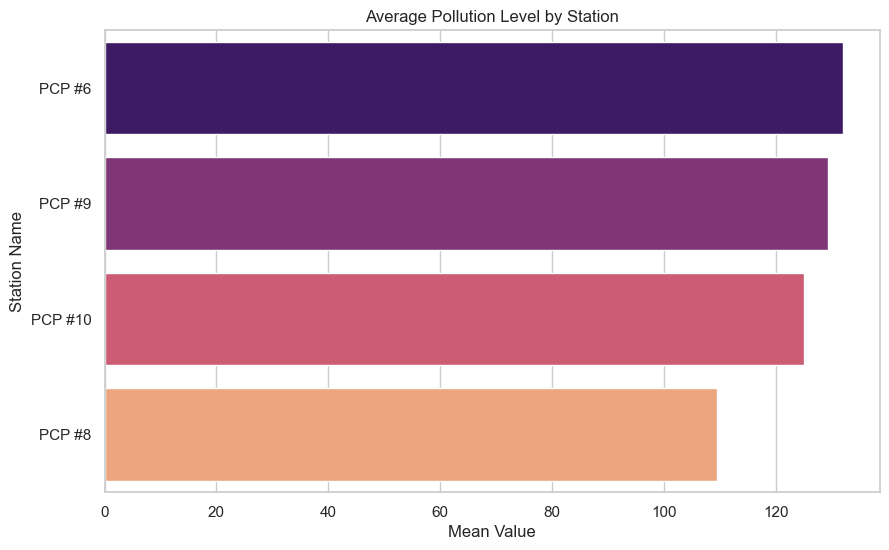

In [9]:
station_avg = df.groupby('name')['value'].mean().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=station_avg.values, y=station_avg.index, palette='magma')
plt.title('Average Pollution Level by Station')
plt.xlabel('Mean Value')
plt.ylabel('Station Name')
plt.show()


The analysis shows clear differences in pollution levels across stations.

PCP #6 has the highest overall pollution levels, followed by PCP #9 and PCP #10, while PCP #8 shows the lowest values.

This suggests that certain locations are more affected by pollution, likely due to proximity to industrial zones, traffic, or other local emission sources.

Overall, pollution is unevenly distributed across the city, highlighting the importance of location-specific analysis.

### Annual Mean Pollution by Station

This chart presents the average annual concentration of different pollutants across stations to identify long-term spatial patterns.

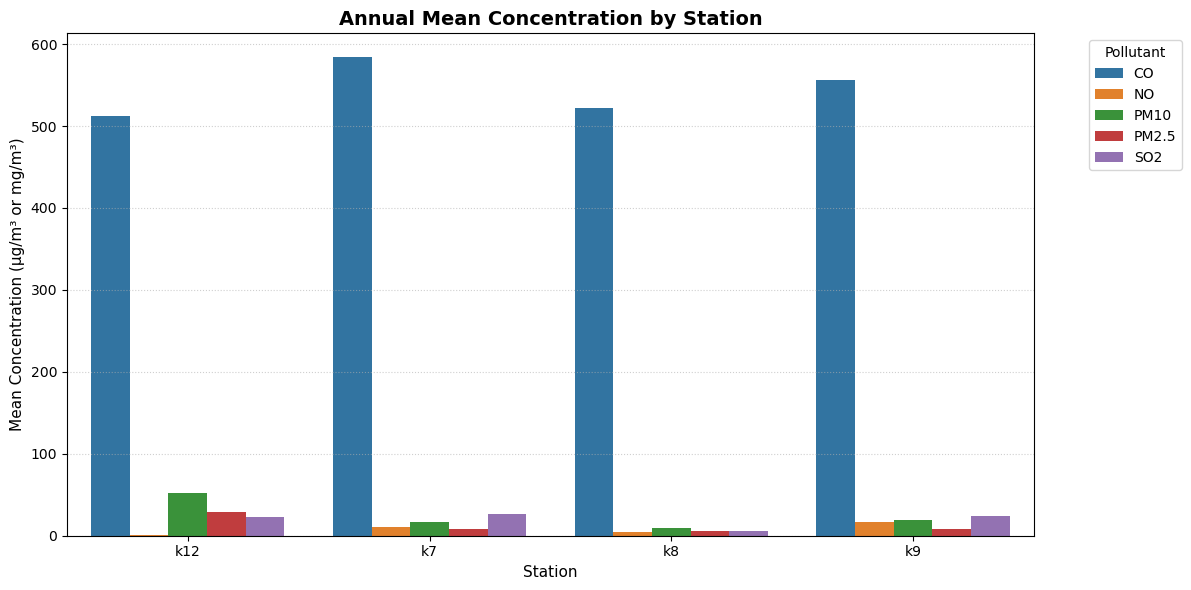

In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("merged_air_data.csv", sep=';')
df.columns = [c.strip().lower() for c in df.columns]
df["value"] = pd.to_numeric(df["value"].astype(str).str.replace(",", ".", regex=False), errors="coerce")

if "datetime" not in df.columns:
    if {"date", "time"}.issubset(df.columns):
        df["datetime"] = pd.to_datetime(df["date"].astype(str) + " " + df["time"].astype(str), errors="coerce")
    elif "date" in df.columns:
        df["datetime"] = pd.to_datetime(df["date"], errors="coerce")


df['date'] = df['datetime'].dt.date
daily = df.groupby(['stationid', 'code', 'date'], as_index=False)['value'].mean()


annual = daily.groupby(['stationid', 'code'], as_index=False)['value'].mean()


plt.figure(figsize=(12,6))
sns.barplot(data=annual, x='stationid', y='value', hue='code')

plt.title("Annual Mean Concentration by Station", fontsize=14, weight='bold')
plt.xlabel("Station", fontsize=11)
plt.ylabel("Mean Concentration (µg/m³ or mg/m³)", fontsize=11)
plt.legend(title="Pollutant", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle=':', alpha=0.6)
plt.tight_layout()
plt.show()


The annual averages reveal noticeable spatial variation in pollution levels across stations.

PCP #7 and PCP #9 show relatively high concentrations for several pollutants, while PCP #8 generally has lower levels.

Particulate matter (PM2.5 and PM10) and SO2 show more variation between stations compared to CO, which remains relatively high but more uniform.

These results indicate that some areas consistently experience higher pollution levels, likely due to persistent local emission sources.

### Correlation Between Pollutants

This heatmap shows the correlation between major pollutants measured in Astana. Correlation analysis helps identify which pollutants tend to increase or decrease together, suggesting possible common sources or similar environmental behavior.

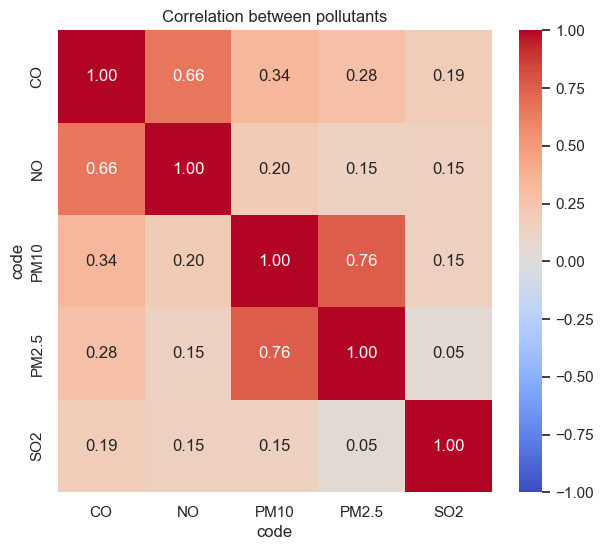

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt


pollutants = ['CO', 'NO', 'PM10', 'SO2', 'PM2.5']


pivot = (df[df['code'].isin(pollutants)]
           .pivot_table(index=['datetime', 'stationId'], 
                        columns='code', 
                        values='value',
                        aggfunc='mean'))


corr = pivot.corr()


plt.figure(figsize=(7,6))
sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title("Correlation between pollutants")
plt.show()


The strongest positive correlation is observed between PM10 and PM2.5 (0.76), indicating that these two pollutants often vary together and may share common sources.

A moderate positive correlation is found between CO and NO (0.66), suggesting a possible link to combustion-related emissions.

The relationships between SO2 and the other pollutants are weak, which indicates that SO2 may behave more independently and could be influenced by different emission sources.

Overall, the heatmap suggests that particulate matter pollutants are closely related, while gaseous pollutants show more mixed and weaker associations.

## Final Conclusion and Recommendations

The results from the analysis show that there are patterns in the level of air pollution at different stations, pollutants, and time periods in Astana.

### Key Findings

- First, the level of pollution varies from one station to another. For instance, PCP #6 always shows the highest level of pollution, while PCP #8 shows the lowest level. This shows that air pollution is not uniform throughout the city, with different stations having different environmental conditions.

- Second, the results show that the level of pollution is seasonal. For instance, the level of pollution is higher during the heating period. This shows that the level of pollution is affected by the process of heating.

- Third, different pollutants show different patterns. For instance, particulate matters, such as PM10 and PM2.5, show significant correlation, while gases, such as SO2, show different patterns.

- Finally, correlation analysis shows that different pollutants show different degrees of correlation. For instance, both PM10 and PM2.5 show significant correlation, while other pollutants show different results.

---

### Recommendations

The results from the analysis show that in order to improve the quality of air, certain actions need to be taken, especially with regard to the key sources of pollution.

---

 Heating and Energy

- Switch from coal-based energy to cleaner energy sources, especially in private housing  
- Develop gas infrastructure, particularly in areas with the highest pollution levels  
- Offer financial assistance or subsidies to support the transition to cleaner energy  

---

 Infrastructure

- Modernization of TECs and boiler houses, equipping them with advanced filters and emission control systems  
- Increase the energy efficiency of buildings, especially to reduce heating demand  

---

 Monitoring and Control

- Improve monitoring in high-risk areas, especially stations with consistently high pollution levels (e.g., PCP #6)  
- Introduce real-time monitoring systems with open access  
- Apply data analysis and AI to predict pollution patterns  

---

 Industry

- Enforce environmental regulations  
- Introduce penalties for high emissions and incentives for cleaner technologies  
- Modernize or upgrade the most polluting industrial facilities  

---

 Transport

- Reduce emissions by developing public transportation  
- Transition to electric or gas-powered buses  
- Limit the use of old vehicles with high emissions  
- Introduce low-emission zones in highly polluted areas  

---

 PM2.5 and PM10 Reduction

- Introduce advanced filtration systems at major emission sources  
- Control dust from construction sites and roads  
- Increase green spaces to reduce particulate concentration  
- Construction activity may also contribute to higher levels of PM10 and PM2.5, as dust from building sites and roads can increase particulate concentration, especially in rapidly developing urban areas like Astana
---

 Local Analysis

- Perform detailed local analysis to identify specific pollution sources  
- Divide the city into risk zones and apply targeted solutions  
- Implement seasonal measures, especially during the heating period  

---

### Final Conclusion

In conclusion, the analysis shows that air pollution in Astana is seasonal and location-dependent. It is influenced by heating, transport, and industrial activity.

To reduce air pollution in the city, a comprehensive approach is required, including infrastructure improvement, regulation, and transition to cleaner technologies.

Following these recommendations is not optional if the goal is to reduce pollution levels rather than simply observe the problem

